In [ ]:
#importing libraries
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, accuracy_score
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

In [ ]:
# loading Dataset
data = pd.read_excel("X.xlsx")
keywords = pd.read_excel("KEYWORDS.xlsx")

In [ ]:
data.shape

(2023, 38)

In [ ]:
data.head()

,account_handle,tweet_id,post_url,description,date,time,bookmark_count,reply_count,retweet_count,favourite_count,...,related_hashtag_10,image_1,image_2,image_3,image_4,description_score,hashtags_score,description_hashtags_similarity_score,recruitment_type,month_year
0,CAGEintl,1741200000000000000,https://x.com/Cageintl/status/1741197365891964968,This is the genocidal practice of settler-colo...,2023-12-30,20:39:36,0,0,9,14,...,NaN,NaN,NaN,NaN,NaN,-0.7579,NaN,NaN,Hard,2023-12
1,CAGEintl,1741090000000000000,https://x.com/Cageintl/status/1741093258350997673,Strip the citizenship of tax exiles like Sajid...,2023-12-30,13:45:55,0,1,14,14,...,NaN,NaN,NaN,NaN,NaN,-0.2960,NaN,NaN,Hard,2023-12
2,CAGEintl,1741050000000000000,https://x.com/Cageintl/status/1741047695911886950,Mainstream politicians elected by the majority...,2023-12-30,10:44:52,1,1,40,47,...,NaN,https://pbs.twimg.com/media/GCjIBuXWsAA2iue.jpg,NaN,NaN,NaN,0.7845,0.0,0.164038,Hard,2023-12
3,CAGEintl,1740860000000000000,https://x.com/Cageintl/status/1740864883741319467,"""UK arms sale to Saudi Arabia"" is an extortio...",2023-12-29,22:38:26,4,3,36,44,...,NaN,https://pbs.twimg.com/media/GCg_aEkWMAAxT0X.jpg,NaN,NaN,NaN,0.4939,NaN,NaN,Hard,2023-12
4,CAGEintl,1740830000000000000,https://x.com/Cageintl/status/1740829573619855789,"Former victim of white settler colonialism, S...",2023-12-29,20:18:08,0,5,66,119,...,NaN,https://pbs.twimg.com/media/GCiDOU_XYAA-SdR.jpg,NaN,NaN,NaN,-0.4927,NaN,NaN,Soft,2023-12


In [ ]:
data.tail()

,account_handle,tweet_id,post_url,description,date,time,bookmark_count,reply_count,retweet_count,favourite_count,...,related_hashtag_10,image_1,image_2,image_3,image_4,description_score,hashtags_score,description_hashtags_similarity_score,recruitment_type,month_year
2018,CAGEintl,1831360000000000000,https://x.com/Cageintl/status/1831357272485941662,"""When writing against the establishment of a P...",2024-09-04,15:42:53,1,0,4,5,...,NaN,https://pbs.twimg.com/media/GWoZIdfXwAAha_a.jpg,NaN,NaN,NaN,0.0000,NaN,NaN,Hard,2024-09
2019,CAGEintl,1831020000000000000,https://x.com/Cageintl/status/1831021400926114127,"This is standard policing once a ""terrorism"" ...",2024-09-03,17:28:15,1,0,18,35,...,NaN,NaN,NaN,NaN,NaN,-0.6808,NaN,NaN,Hard,2024-09
2020,CAGEintl,1830990000000000000,https://x.com/Cageintl/status/1830991015919939723,"If we had an equal system of laws, the Board o...",2024-09-03,15:27:31,6,11,175,351,...,NaN,https://pbs.twimg.com/media/GWjB2nvXAAQHTCe.jpg,NaN,NaN,NaN,0.6808,NaN,NaN,General,2024-09
2021,CAGEintl,1830980000000000000,https://x.com/Cageintl/status/1830977979238977622,There is no justification for Terrorism laws. ...,2024-09-03,14:35:42,0,1,20,31,...,NaN,NaN,NaN,NaN,NaN,-0.9382,NaN,NaN,Hard,2024-09
2022,CAGEintl,1830970000000000000,https://x.com/Cageintl/status/1830973144758206843,"""Radio Rwanda in full effect here.""Chief Rabbi...",2024-09-03,14:16:30,1,0,13,25,...,NaN,NaN,NaN,NaN,NaN,0.4588,NaN,NaN,Hard,2024-09


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2023 entries, 0 to 2022
Data columns (total 38 columns):
 #   Column                                 Non-Null Count  Dtype         
---  ------                                 --------------  -----         
 0   account_handle                         2023 non-null   object        
 1   tweet_id                               2023 non-null   int64         
 2   post_url                               2023 non-null   object        
 3   description                            2023 non-null   object        
 4   date                                   2023 non-null   datetime64[ns]
 5   time                                   2023 non-null   object        
 6   bookmark_count                         2023 non-null   int64         
 7   reply_count                            2023 non-null   int64         
 8   retweet_count                          2023 non-null   int64         
 9   favourite_count                        2023 non-null   int64   

In [ ]:
data.describe()

,tweet_id,date,bookmark_count,reply_count,retweet_count,favourite_count,view_count,related_hashtag_10,description_score,hashtags_score,description_hashtags_similarity_score
count,2.023000e+03,2023,2023.000000,2023.000000,2023.000000,2023.000000,2023.000000,0.0,2023.000000,236.000000,236.000000
mean,1.802863e+18,2024-06-17 09:05:14.977755904,2.122096,3.416214,30.483440,58.481463,3193.815126,NaN,-0.206507,-0.000897,0.346925
min,1.737810e+18,2023-12-21 00:00:00,0.000000,0.000000,0.000000,0.000000,10.000000,NaN,-0.984400,-0.510600,-0.040645
25%,1.770465e+18,2024-03-20 00:00:00,0.000000,0.000000,5.000000,9.000000,785.000000,NaN,-0.726250,0.000000,0.241086
50%,1.802070e+18,2024-06-15 00:00:00,0.000000,1.000000,12.000000,21.000000,1283.000000,NaN,-0.303100,0.000000,0.343636
75%,1.834935e+18,2024-09-14 00:00:00,2.000000,2.000000,28.000000,51.000000,2357.000000,NaN,0.273200,0.000000,0.452587
max,1.873860e+18,2024-12-30 00:00:00,149.000000,1040.000000,2894.000000,5203.000000,265162.000000,NaN,0.985600,0.273200,0.873629
std,3.786225e+16,NaN,7.675054,26.693349,100.057726,203.857829,10665.159962,NaN,0.564309,0.037803,0.153986


In [ ]:
text_column = "description"
target_column = "recruitment_type"

data = data[[text_column, target_column]].dropna()

In [ ]:
data.shape

(2023, 2)

In [ ]:
data['recruitment_type'].value_counts()

,count
recruitment_type,
Hard,1138
General,471
Soft,414


In [ ]:
#creating dictionary for keywords
keyword_dict = {}

for col in keywords.columns:
    keyword_dict[col] = keywords[col].dropna().str.lower().tolist()


In [ ]:
#Keyword Feature Engineering
def keyword_features(text):

    text = text.lower()
    features = {}

    for category, words in keyword_dict.items():
        count = sum(word in text for word in words)
        features[category + "_count"] = count

    return pd.Series(features)

keyword_df = data[text_column].apply(keyword_features)

#combining with dataset
data = pd.concat([data, keyword_df], axis=1)


In [ ]:
# TEXT PREPROCESSING

import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

nltk.download('stopwords')
nltk.download('wordnet')

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    text = text.lower()
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"[^a-zA-Z ]", "", text)

    words = text.split()
    words = [lemmatizer.lemmatize(w) for w in words if w not in stop_words]

    return " ".join(words)

data["clean_text"] = data["description"].apply(clean_text)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from scipy.sparse import hstack

# TF-IDF
vectorizer = TfidfVectorizer(
    stop_words='english',
    max_features=5000,
    ngram_range=(1,2)
)

X_tfidf = vectorizer.fit_transform(data['clean_text'])

# Combine with keyword features
X = hstack([X_tfidf, keyword_df.values])

# Labels
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y = le.fit_transform(data['recruitment_type'])

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression

param_grid = {
    'C': [0.01, 0.1, 1, 10],
    'penalty': ['l2'],
    'solver': ['lbfgs']
}

grid_lr = GridSearchCV(
    LogisticRegression(max_iter=1000),
    param_grid,
    cv=5,
    scoring='f1_weighted'
)

grid_lr.fit(X_train, y_train)

best_lr = grid_lr.best_estimator_
print("Best LR Params:", grid_lr.best_params_)

Best LR Params: {'C': 10, 'penalty': 'l2', 'solver': 'lbfgs'}


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5]
}

grid_rf = GridSearchCV(
    RandomForestClassifier(),
    param_grid,
    cv=3,
    scoring='f1_weighted'
)

grid_rf.fit(X_train, y_train)

best_rf = grid_rf.best_estimator_

print("Best RF Params:", grid_rf.best_params_)

Best RF Params: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 100}


In [ ]:
from sklearn.svm import SVC

param_grid = {
    'C': [0.1, 1, 10],
    'kernel': ['linear', 'rbf'],
    'gamma': ['scale', 'auto']
}

grid_svm = GridSearchCV(
    SVC(probability=True),
    param_grid,
    cv=3,
    scoring='f1_weighted'
)

grid_svm.fit(X_train, y_train)

best_svm = grid_svm.best_estimator_
print("Best SVM Params:", grid_svm.best_estimator_)

Best SVM Params: SVC(C=10, kernel='linear', probability=True)


In [ ]:
from sklearn.naive_bayes import MultinomialNB

nb_param_grid = {
    'alpha': [0.01, 0.1, 0.5, 1.0, 5.0]
}

# Grid search
grid_nb = GridSearchCV(
    MultinomialNB(),
    nb_param_grid,
    cv=3,
    scoring='f1_weighted'
)

grid_nb.fit(X_train, y_train)

# Best model
best_nb = grid_nb.best_estimator_

print("Best NB Params:", grid_nb.best_params_)

Best NB Params: {'alpha': 0.1}


In [ ]:
lr_pred = best_lr.predict(X_test)
lr_accuracy = accuracy_score(y_test, lr_pred)

rf_pred = best_rf.predict(X_test)
rf_accuracy = accuracy_score(y_test, rf_pred)

svm_pred = best_svm.predict(X_test)
svm_accuracy = accuracy_score(y_test, svm_pred)

nb_pred = best_nb.predict(X_test)
nb_accuracy = accuracy_score(y_test, nb_pred)

print(f"Logistic Regression Accuracy: {lr_accuracy}")
print(f"Random Forest Accuracy: {rf_accuracy}")
print(f"SVM Accuracy: {svm_accuracy}")
print(f"Naive Bayes Accuracy: {nb_accuracy}")

Logistic Regression Accuracy: 0.6049382716049383
Random Forest Accuracy: 0.6098765432098765
SVM Accuracy: 0.5654320987654321
Naive Bayes Accuracy: 0.5580246913580247


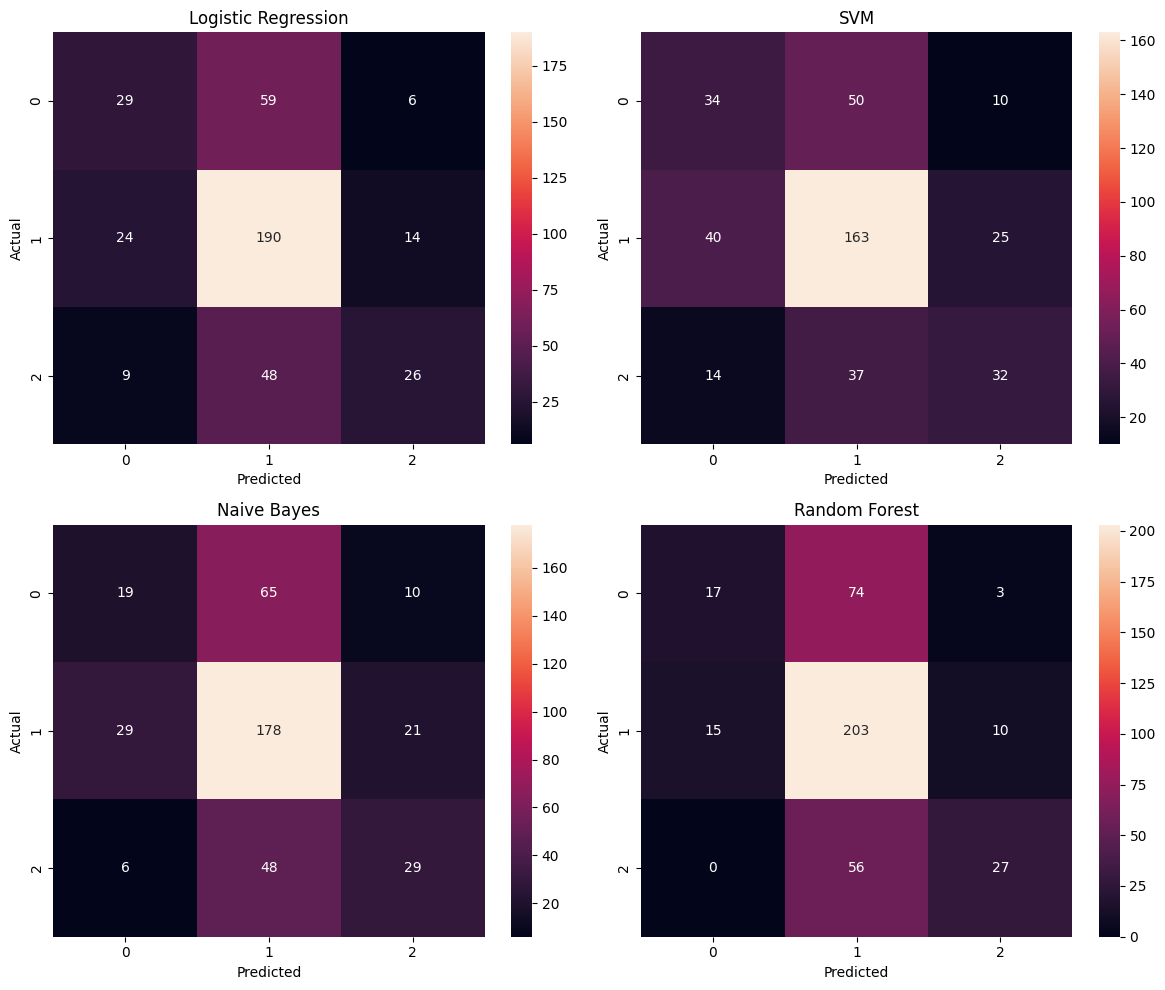

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

models = {
    "Logistic Regression": best_lr,
    "SVM": best_svm,
    "Naive Bayes": best_nb,
    "Random Forest": best_rf
}

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for i, (name, model) in enumerate(models.items()):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)

    sns.heatmap(cm, annot=True, fmt='d', ax=axes[i])
    axes[i].set_title(name)
    axes[i].set_xlabel("Predicted")
    axes[i].set_ylabel("Actual")

plt.tight_layout()
plt.show()

In [ ]:
print(classification_report(y_test, lr_pred))

              precision    recall  f1-score   support

           0       0.47      0.31      0.37        94
           1       0.64      0.83      0.72       228
           2       0.57      0.31      0.40        83

    accuracy                           0.60       405
   macro avg       0.56      0.49      0.50       405
weighted avg       0.58      0.60      0.58       405



In [ ]:
from sklearn.model_selection import cross_val_score
import numpy as np

models = {
    "Logistic Regression": best_lr,
    "SVM": best_svm,
    "Naive Bayes": best_nb,
    "Random Forest": best_rf
}

cv_results = {}

for name, model in models.items():
    scores = cross_val_score(model, X_train, y_train, cv=5, scoring='accuracy')
    cv_results[name] = scores

    print(f"\n{name}")
    print("Mean CV Score:", np.mean(scores))


Logistic Regression
Mean CV Score: 0.600099376982762

SVM
Mean CV Score: 0.576636853571838

Naive Bayes
Mean CV Score: 0.5636471352673623

Random Forest
Mean CV Score: 0.6421434850743417


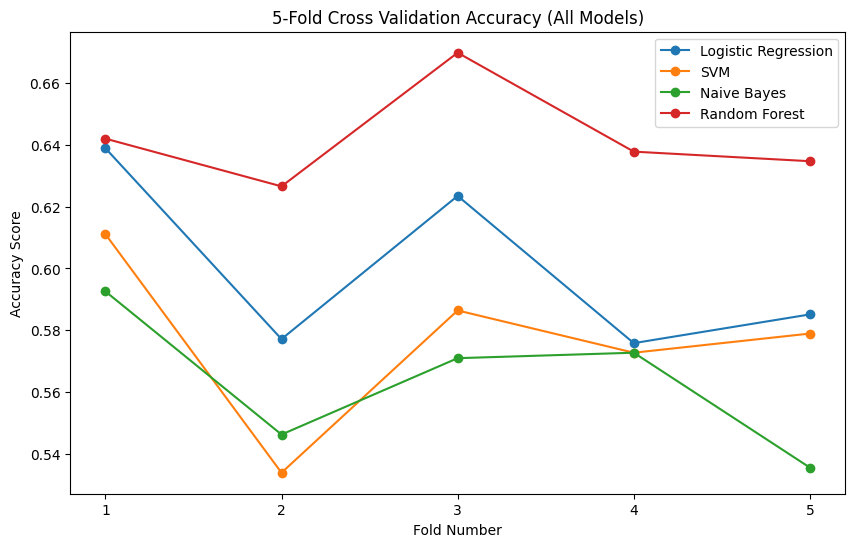

In [ ]:
# Plot
plt.figure(figsize=(10, 6))

for name, scores in cv_results.items():
    plt.plot(range(1, 6), scores, marker='o', label=name)

plt.title("5-Fold Cross Validation Accuracy (All Models)")
plt.xlabel("Fold Number")
plt.ylabel("Accuracy Score")
plt.xticks(range(1, 6))
plt.legend()
plt.show()


In [ ]:
import pandas as pd
from sklearn.metrics import classification_report

# Calculate classification report metrics for each model
lr_report = classification_report(y_test, lr_pred, output_dict=True)
rf_report = classification_report(y_test, rf_pred, output_dict=True)
svm_report = classification_report(y_test, svm_pred, output_dict=True)
nb_report = classification_report(y_test, nb_pred, output_dict=True)

lr_precision = lr_report['weighted avg']['precision']
lr_recall = lr_report['weighted avg']['recall']
lr_f1 = lr_report['weighted avg']['f1-score']

rf_precision = rf_report['weighted avg']['precision']
rf_recall = rf_report['weighted avg']['recall']
rf_f1 = rf_report['weighted avg']['f1-score']

svm_precision = svm_report['weighted avg']['precision']
svm_recall = svm_report['weighted avg']['recall']
svm_f1 = svm_report['weighted avg']['f1-score']

nb_precision = nb_report['weighted avg']['precision']
nb_recall = nb_report['weighted avg']['recall']
nb_f1 = nb_report['weighted avg']['f1-score']

comparison_table = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "SVM",
        "Naive Bayes"
    ],
    "Accuracy": [
        lr_accuracy,
        rf_accuracy,
        svm_accuracy,
        nb_accuracy
    ],
    "Precision (Weighted)": [
        lr_precision,
        rf_precision,
        svm_precision,
        nb_precision
    ],
    "Recall (Weighted)": [
        lr_recall,
        rf_recall,
        svm_recall,
        nb_recall
    ],
    "F1 Score (Weighted)": [
        lr_f1,
        rf_f1,
        svm_f1,
        nb_f1
    ]
})

print(comparison_table)

                 Model  Accuracy  Precision (Weighted)  Recall (Weighted)  \
0  Logistic Regression  0.604938              0.584542           0.604938   
1        Random Forest  0.609877              0.604823           0.609877   
2                  SVM  0.565432              0.554607           0.565432   
3          Naive Bayes  0.558025              0.525073           0.558025   

   F1 Score (Weighted)  
0             0.576382  
1             0.560023  
2             0.558104  
3             0.528870  


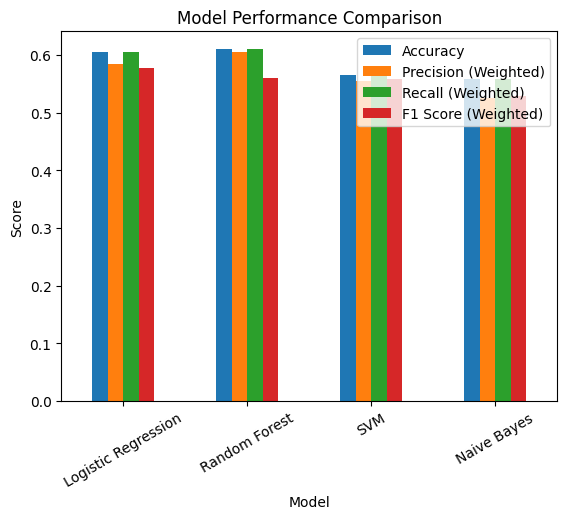

In [ ]:
import matplotlib.pyplot as plt

comparison_table.set_index("Model").plot(kind="bar")

plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.xticks(rotation=30)

plt.show()

In [ ]:
best_model = comparison_table.loc[comparison_table["F1 Score (Weighted)"].idxmax()]

print("Best Performing Model:")
print(best_model)

Best Performing Model:
Model                   Logistic Regression
Accuracy                           0.604938
Precision (Weighted)               0.584542
Recall (Weighted)                  0.604938
F1 Score (Weighted)                0.576382
Name: 0, dtype: object


In [ ]:
errors = X_test[y_test != lr_pred]
print(errors[:5])

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 123 stored elements and shape (5, 5003)>
  Coords	Values
  (0, 62)	0.15516290661254853
  (0, 915)	0.21816523386522593
  (0, 950)	0.223209589380088
  (0, 995)	0.23647784195258106
  (0, 1068)	0.20337468182780477
  (0, 1186)	0.22917579563699483
  (0, 1323)	0.18725910921841513
  (0, 1351)	0.18725910921841513
  (0, 1632)	0.06088412589290808
  (0, 1639)	0.20052736179090816
  (0, 1813)	0.21816523386522593
  (0, 1898)	0.19790808126402398
  (0, 1901)	0.23647784195258106
  (0, 2844)	0.38222677354844276
  (0, 2845)	0.206493568047815
  (0, 2846)	0.23647784195258106
  (0, 3907)	0.17650929414304892
  (0, 3908)	0.19790808126402398
  (0, 3923)	0.21816523386522593
  (0, 4159)	0.22917579563699483
  (0, 4332)	0.18381134045863515
  (0, 4997)	0.15192030176781982
  (0, 5000)	1.0
  (0, 5001)	2.0
  (0, 5002)	2.0
  :	:
  (4, 829)	0.1797592458743624
  (4, 1076)	0.22205679605138587
  (4, 1077)	0.21269144066446474
  (4, 1434)	0.18629198655829454
  (4, 

In [ ]:
def predict_news(text):

    cleaned = clean_text(text)

    tfidf_vec = vectorizer.transform([cleaned])

    keyword_vec = keyword_features(text).values.reshape(1, -1)

    from scipy.sparse import hstack
    final_vec = hstack([tfidf_vec, keyword_vec])

    prediction = best_lr.predict(final_vec)[0]

    return le.inverse_transform([prediction])[0]

In [ ]:
test_cases = [
    "Government announces free money scheme",
    "NASA launches new satellite mission",
    "Earn 10k daily working from home click link"
]

for t in test_cases:
    print(t, "→", predict_news(t))

Government announces free money scheme → Hard
NASA launches new satellite mission → Hard
Earn 10k daily working from home click link → Hard


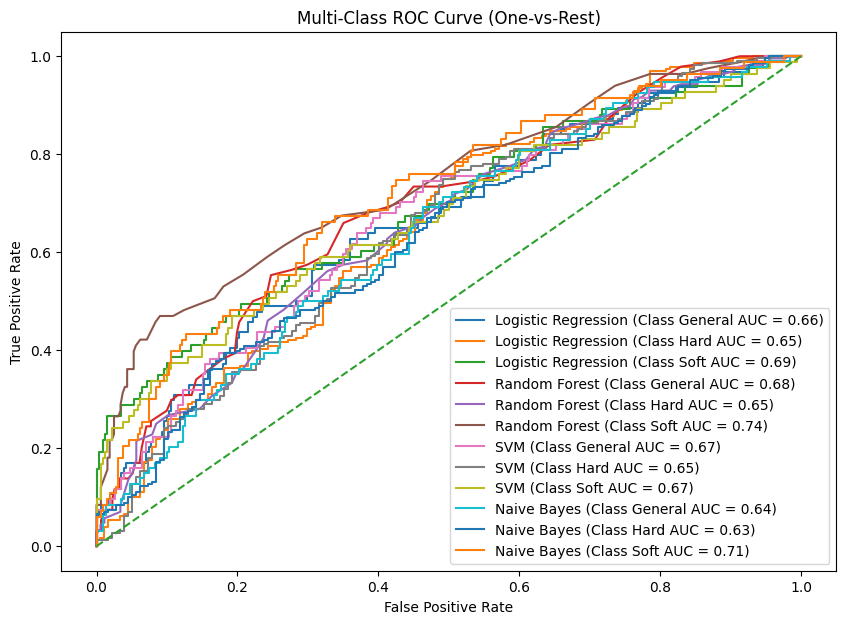

In [ ]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import numpy as np

# Binarize labels
classes = np.unique(y_test)
y_test_bin = label_binarize(y_test, classes=classes)
n_classes = y_test_bin.shape[1]

# Get probabilities
lr_probs = best_lr.predict_proba(X_test)
rf_probs = best_rf.predict_proba(X_test)
svm_probs = best_svm.predict_proba(X_test)
nb_probs = best_nb.predict_proba(X_test)

models_probs = {
    "Logistic Regression": lr_probs,
    "Random Forest": rf_probs,
    "SVM": svm_probs,
    "Naive Bayes": nb_probs
}

# Plot
plt.figure(figsize=(10, 7))

for model_name, probs in models_probs.items():
    for i in range(n_classes):
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], probs[:, i])
        roc_auc = auc(fpr, tpr)

        plt.plot(
            fpr, tpr,
            label=f"{model_name} (Class {le.inverse_transform([i])[0]} AUC = {roc_auc:.2f})"
        )

# Random baseline
plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Multi-Class ROC Curve (One-vs-Rest)")
plt.legend()
plt.show()

In [ ]:
from sklearn.metrics import roc_auc_score

# Calculating AUC values

lr_auc = roc_auc_score(y_test_bin, lr_probs, multi_class="ovr")
rf_auc = roc_auc_score(y_test_bin, rf_probs, multi_class="ovr")
svm_auc = roc_auc_score(y_test_bin, svm_probs, multi_class="ovr")
nb_auc = roc_auc_score(y_test_bin, nb_probs, multi_class="ovr")

print("Logistic Regression AUC:", lr_auc)
print("Random Forest AUC:", rf_auc)
print("SVM AUC:", svm_auc)
print("Naive Bayes AUC:", nb_auc)

Logistic Regression AUC: 0.6686791799840481
Random Forest AUC: 0.6928898912494533
SVM AUC: 0.661554065662422
Naive Bayes AUC: 0.6627602508835483


In [ ]:
from transformers import pipeline

In [ ]:
classifier = pipeline(
    "text-classification",
    model="mrm8488/bert-tiny-finetuned-fake-news-detection"
)

Loading weights:   0%|          | 0/41 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: mrm8488/bert-tiny-finetuned-fake-news-detection
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [ ]:
text = "Earn $5000 per day working from home. No experience required!"

result = classifier(text)
print(result)

[{'label': 'LABEL_1', 'score': 0.9990946054458618}]


In [ ]:
def detect_scam_news(news_text):

    # ✅ Apply SAME preprocessing
    cleaned = clean_text(news_text)

    # TF-IDF
    tfidf_vec = vectorizer.transform([cleaned])

    # Keyword features (can use original or cleaned — both OK, but be consistent)
    keyword_vec = keyword_features(news_text).values.reshape(1, -1)

    from scipy.sparse import hstack
    text_vector = hstack([tfidf_vec, keyword_vec])

    # ML prediction (now correctly using Logistic Regression ✅)
    ml_pred = best_lr.predict(text_vector)[0]

    label_map = {
        "Hard": "Scam",
        "Soft": "Possible Scam",
        "Real": "Legitimate"
    }

    final_label = label_map.get(
        le.inverse_transform([ml_pred])[0],
        "Unknown"
    )

    return final_label

In [ ]:
news = input("Enter social media news: ")

result = detect_scam_news(news)

print(result)

Enter social media news: government is giving free jobs
Scam


In [ ]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Conv1D, GlobalMaxPooling1D, Dense, Dropout
from sklearn.preprocessing import LabelEncoder

In [ ]:
# Tokenization
max_words = 10000
max_len = 200

tokenizer = Tokenizer(num_words=max_words)
tokenizer.fit_on_texts(data[text_column])

X_seq = tokenizer.texts_to_sequences(data[text_column])
X_pad = pad_sequences(X_seq, maxlen=max_len)

In [ ]:
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(data[target_column])

In [ ]:
from tensorflow.keras.layers import Input, LSTM

lstm_model = Sequential([
    Input(shape=(max_len,)),   # ✅ THIS FIXES EVERYTHING

    Embedding(input_dim=max_words, output_dim=128),

    LSTM(64),

    Dropout(0.5),

    Dense(64, activation='relu'),

    Dense(len(set(y_encoded)), activation='softmax')
])

In [ ]:
lstm_model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ (None, 200, 128)       │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,333,763 (5.09 MB)

 Trainable params: 1,333,763 (5.09 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
lstm_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
from tensorflow.keras.layers import Bidirectional

bilstm_model = Sequential([
    Input(shape=(max_len,)),

    Embedding(input_dim=max_words, output_dim=128),

    Bidirectional(LSTM(64)),

    Dropout(0.5),

    Dense(64, activation='relu'),

    Dense(len(set(y_encoded)), activation='softmax')
])

bilstm_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

bilstm_model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_4 (Embedding)         │ (None, 200, 128)       │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 128)            │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,387,267 (5.29 MB)

 Trainable params: 1,387,267 (5.29 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
from tensorflow.keras.layers import GRU

gru_model = Sequential([
    Input(shape=(max_len,)),

    Embedding(input_dim=max_words, output_dim=128),

    GRU(64),

    Dropout(0.5),

    Dense(64, activation='relu'),

     Dense(len(set(y_encoded)), activation='softmax')
])

gru_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

gru_model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_5 (Embedding)         │ (None, 200, 128)       │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ (None, 64)             │        37,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,321,603 (5.04 MB)

 Trainable params: 1,321,603 (5.04 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
from sklearn.model_selection import train_test_split

X_train_cnn, X_test_cnn, y_train_cnn, y_test_cnn = train_test_split(
    X_pad, y_encoded, test_size=0.2, random_state=42
)

In [ ]:
lstm_history  = lstm_model.fit(
    X_train_cnn, y_train_cnn,
    epochs=10,
    batch_size=32,
    validation_split=0.1)

Epoch 1/10
46/46 ━━━━━━━━━━━━━━━━━━━━ 6s 21ms/step - accuracy: 0.5556 - loss: 1.0070 - val_accuracy: 0.5000 - val_loss: 1.0258
Epoch 2/10
46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.6573 - loss: 0.7532 - val_accuracy: 0.6235 - val_loss: 0.9581
Epoch 3/10
46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.8345 - loss: 0.4164 - val_accuracy: 0.6543 - val_loss: 0.9393
Epoch 4/10
46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.9299 - loss: 0.1925 - val_accuracy: 0.7469 - val_loss: 0.8746
Epoch 5/10
46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.9904 - loss: 0.0540 - val_accuracy: 0.7037 - val_loss: 1.0610
Epoch 6/10
46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.9945 - loss: 0.0263 - val_accuracy: 0.7284 - val_loss: 1.1276
Epoch 7/10
46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.9938 - loss: 0.0215 - val_accuracy: 0.7654 - val_loss: 1.0650
Epoch 8/10
46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.9979 - loss: 0.0081 - val_accuracy: 0.7531 - v

In [ ]:
bilstm_history =bilstm_model.fit(
   X_train_cnn, y_train_cnn,
    epochs=10,
    batch_size=32,
    validation_split=0.1
)

Epoch 1/10
46/46 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step - accuracy: 0.5543 - loss: 0.9955 - val_accuracy: 0.4938 - val_loss: 1.0292
Epoch 2/10
46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.6841 - loss: 0.7426 - val_accuracy: 0.6420 - val_loss: 0.8298
Epoch 3/10
46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.8345 - loss: 0.4501 - val_accuracy: 0.6420 - val_loss: 0.9067
Epoch 4/10
46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.9540 - loss: 0.1609 - val_accuracy: 0.7037 - val_loss: 0.9006
Epoch 5/10
46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.9918 - loss: 0.0389 - val_accuracy: 0.7284 - val_loss: 1.3530
Epoch 6/10
46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 0.9986 - loss: 0.0122 - val_accuracy: 0.7469 - val_loss: 1.2679
Epoch 7/10
46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 1.0000 - loss: 0.0032 - val_accuracy: 0.7716 - val_loss: 1.2908
Epoch 8/10
46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 1.0000 - loss: 0.0015 - val_accuracy: 0.7654 - v

In [ ]:
gru_history =gru_model.fit(
    X_train_cnn, y_train_cnn,
    epochs=10,
    batch_size=32,
    validation_split=0.1
)

Epoch 1/10
46/46 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.5563 - loss: 1.0167 - val_accuracy: 0.4938 - val_loss: 1.0336
Epoch 2/10
46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.5824 - loss: 0.8653 - val_accuracy: 0.6049 - val_loss: 1.0600
Epoch 3/10
46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.7308 - loss: 0.7484 - val_accuracy: 0.5370 - val_loss: 1.1530
Epoch 4/10
46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.8530 - loss: 0.3858 - val_accuracy: 0.5432 - val_loss: 1.4097
Epoch 5/10
46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.9444 - loss: 0.1785 - val_accuracy: 0.5926 - val_loss: 1.5781
Epoch 6/10
46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.9863 - loss: 0.0627 - val_accuracy: 0.6049 - val_loss: 1.7120
Epoch 7/10
46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.9897 - loss: 0.0402 - val_accuracy: 0.6111 - val_loss: 1.9423
Epoch 8/10
46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.9931 - loss: 0.0251 - val_accuracy: 0.6173 - v

In [ ]:
from sklearn.metrics import accuracy_score

lstm_pred = lstm_model.predict(X_test_cnn).argmax(axis=1)
bilstm_pred = bilstm_model.predict(X_test_cnn).argmax(axis=1)
gru_pred = gru_model.predict(X_test_cnn).argmax(axis=1)

lstm_acc = accuracy_score(y_test_cnn, lstm_pred)
bilstm_acc = accuracy_score(y_test_cnn, bilstm_pred)
gru_acc = accuracy_score(y_test_cnn, gru_pred)

print("LSTM Accuracy:", lstm_acc)
print("BiLSTM Accuracy:", bilstm_acc)
print("GRU Accuracy:", gru_acc)

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
LSTM Accuracy: 0.7654320987654321
BiLSTM Accuracy: 0.7876543209876543
GRU Accuracy: 0.6024691358024692


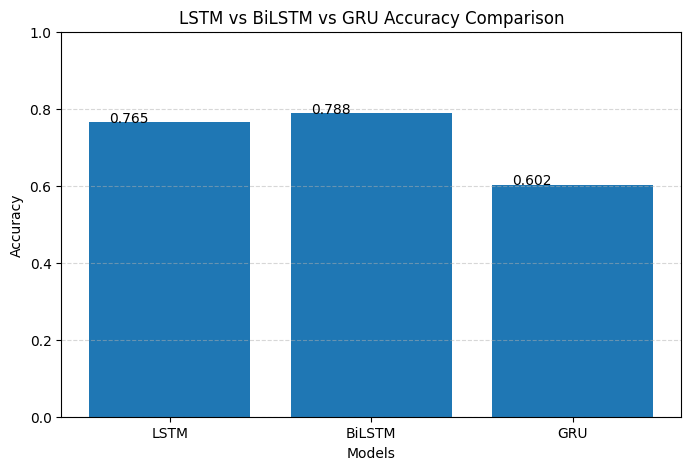

In [ ]:
import matplotlib.pyplot as plt

models = ["LSTM", "BiLSTM", "GRU"]
accuracies = [lstm_acc, bilstm_acc, gru_acc]

plt.figure(figsize=(8,5))

bars = plt.bar(models, accuracies)

# add values on top
for bar in bars:
    plt.text(
        bar.get_x() + 0.1,
        bar.get_height(),
        round(bar.get_height(), 3)
    )

plt.title("LSTM vs BiLSTM vs GRU Accuracy Comparison")
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

In [ ]:
def predict_news(text):

    # convert text to sequence
    seq = tokenizer.texts_to_sequences([text])

    # pad sequence
    padded = pad_sequences(seq, maxlen=max_len)

    # prediction
    pred = bilstm_model.predict(padded)

    predicted_class = pred.argmax(axis=1)[0]

    label = label_encoder.inverse_transform([predicted_class])[0]

    confidence = pred.max()

    print("Input Text:", text)
    print("Prediction:", label)
    print("Confidence:", confidence)

In [ ]:
test_news = "Breaking: Government giving free money if you click this link now"

predict_news(test_news)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 173ms/step
Input Text: Breaking: Government giving free money if you click this link now
Prediction: General
Confidence: 0.50349253
